<a href="https://colab.research.google.com/github/09-ashish/DSA-CaseStudies/blob/main/Supervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay as cm, classification_report as cr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report as cr, accuracy_score, precision_score, recall_score, f1_score,ConfusionMatrixDisplay as cm
from sklearn.model_selection import GridSearchCV

In [33]:
data=pd.read_csv("/content/Training_data.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


**EDA**

In [34]:
data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [36]:
data.duplicated().sum()

np.int64(0)

/tmp/ipykernel_1385/1823932009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Churn', palette='pastel')


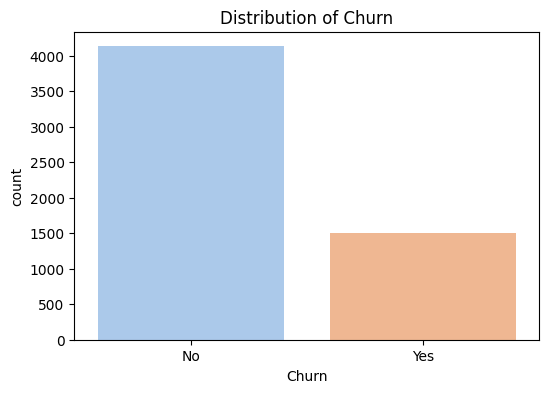

Churn
No     73.304934
Yes    26.695066
Name: proportion, dtype: float64


In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Churn', palette='pastel')
plt.title('Distribution of Churn')
plt.show()

print(data['Churn'].value_counts(normalize=True) * 100)

In [38]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

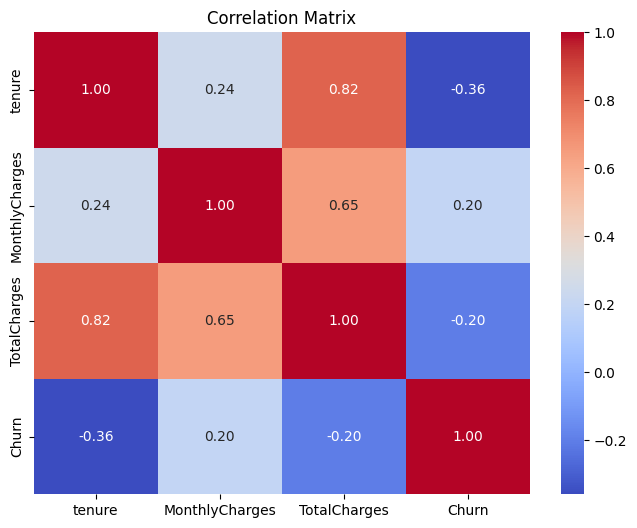

In [39]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

/tmp/ipykernel_1385/2691625912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Churn', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_1385/2691625912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Churn', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_1385/2691625912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Churn', y=col, ax=axes[i], palette='Set2')


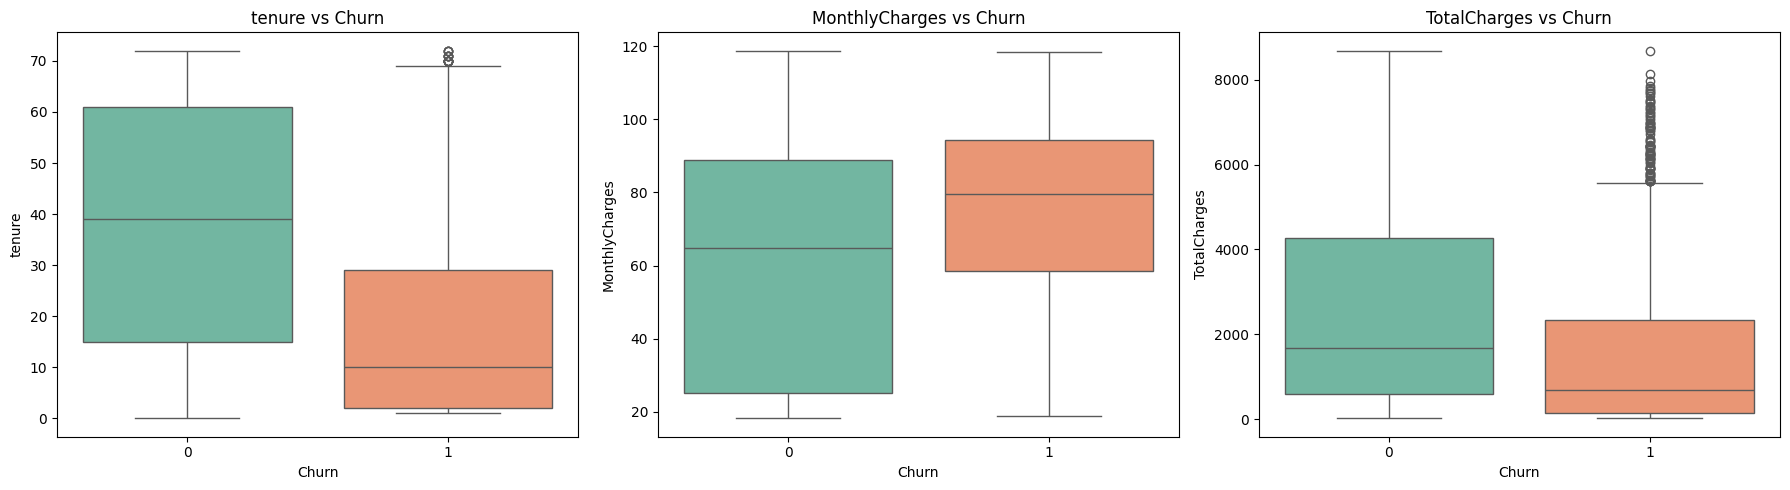

In [40]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=data, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

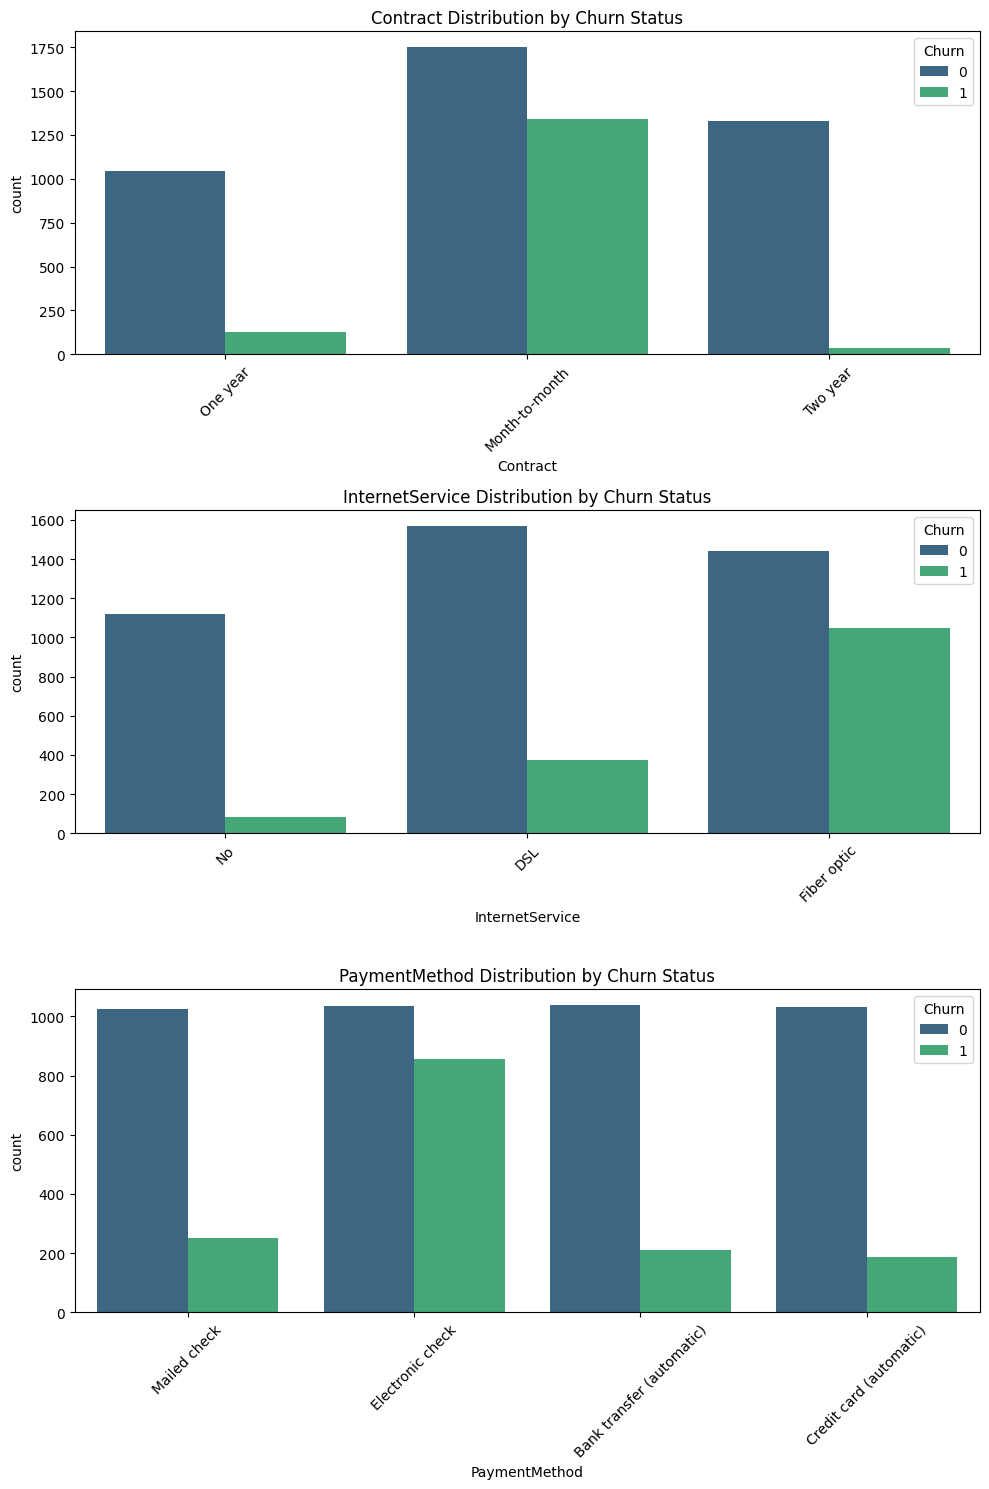

In [41]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=data, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} Distribution by Churn Status')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [42]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [43]:
data=data.dropna(subset=['gender','OnlineSecurity'])
data['MonthlyCharges']=data['MonthlyCharges'].fillna(data['MonthlyCharges'].median())
data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].median())


In [44]:
data=data.drop(columns=['customerID','PhoneService','TotalCharges'])

In [48]:
#Label Encoding
label=LabelEncoder()
data['gender']=label.fit_transform(data['gender'])
data['Partner']=label.fit_transform(data['Partner'])
data['Dependents']=label.fit_transform(data['Dependents'])
data['PaperlessBilling']=label.fit_transform(data['PaperlessBilling'])
data

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,0,0,35,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,20.75,0
1,0,0,0,0,28,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,1,Mailed check,35.75,0
2,1,0,0,0,56,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,0,Electronic check,98.60,0
3,1,0,1,0,39,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,0
5,1,0,0,0,39,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,106.40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5627,0,1,0,0,5,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,0,Electronic check,78.95,1
5628,1,0,0,0,31,No,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,1,Electronic check,78.45,1
5629,1,0,0,0,51,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.00,0
5630,1,1,1,0,68,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,1,Electronic check,41.95,0


In [50]:
#one hot encoding
categorical_cols = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True,dtype=int)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,0,20.75,0,0,0,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,0,28,1,35.75,0,1,0,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0,56,0,98.60,0,0,1,...,0,0,1,0,1,0,0,0,1,0
3,1,0,1,0,39,1,20.45,0,0,0,...,0,1,0,1,0,0,1,0,0,0
5,1,0,0,0,39,1,106.40,0,0,1,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5627,0,1,0,0,5,0,78.95,1,0,0,...,0,0,0,0,1,0,0,0,1,0
5628,1,0,0,0,31,1,78.45,1,0,0,...,1,0,0,0,0,0,0,0,1,0
5629,1,0,0,0,51,1,99.00,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5630,1,1,1,0,68,1,41.95,0,1,0,...,0,0,0,0,0,0,1,0,1,0


**FEATURE ENGINEERING**

In [51]:
data['Lifetime_value_Proxy'] = data['tenure'] * data['MonthlyCharges']

if 'Contract_One year' in data.columns:
    data['Tenure_x_OneYearContract'] = data['tenure'] * data['Contract_One year']
if 'Contract_Two year' in data.columns:
    data['Tenure_x_TwoYearContract'] = data['tenure'] * data['Contract_Two year']

data


,gender,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Lifetime_value_Proxy,Tenure_x_OneYearContract,Tenure_x_TwoYearContract
0,0,0,0,0,35,0,20.75,0,0,0,...,1,0,1,0,0,0,1,726.25,35,0
1,0,0,0,0,28,1,35.75,0,1,0,...,0,0,0,0,0,0,1,1001.00,0,0
2,1,0,0,0,56,0,98.60,0,0,1,...,0,1,0,0,0,1,0,5521.60,0,0
3,1,0,1,0,39,1,20.45,0,0,0,...,1,0,0,1,0,0,0,797.55,0,39
5,1,0,0,0,39,1,106.40,0,0,1,...,0,1,0,0,0,1,0,4149.60,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5627,0,1,0,0,5,0,78.95,1,0,0,...,0,1,0,0,0,1,0,394.75,0,0
5628,1,0,0,0,31,1,78.45,1,0,0,...,0,0,0,0,0,1,0,2431.95,0,0
5629,1,0,0,0,51,1,99.00,0,0,0,...,0,1,0,0,0,1,0,5049.00,0,0
5630,1,1,1,0,68,1,41.95,0,1,0,...,0,0,0,1,0,1,0,2852.60,0,68


**Model Development**

In [54]:
#spliting the data
X=data.drop(columns=['Churn'])
y=data['Churn']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [103]:
#Scaling
num_cols = ['tenure', 'MonthlyCharges', 'Lifetime_value_Proxy']
if 'Tenure_x_OneYearContract' in X_train.columns:
    num_cols.extend(['Tenure_x_OneYearContract', 'Tenure_x_TwoYearContract'])

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       793
           1       0.62      0.54      0.58       267

    accuracy                           0.80      1060
   macro avg       0.74      0.72      0.73      1060
weighted avg       0.79      0.80      0.80      1060



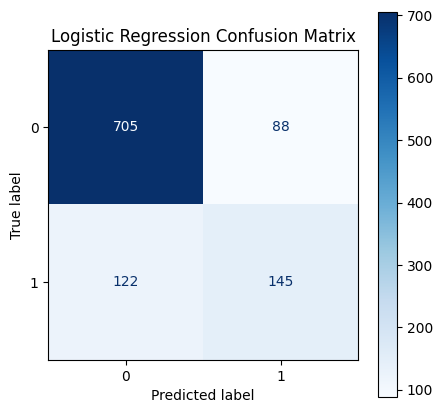

0.8018867924528302


In [67]:
#Logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train,y_train)

y_pred_lr = log_model.predict(X_test)


print(classification_report(y_test, y_pred_lr))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(accuracy_score(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       793
           1       0.60      0.46      0.52       267

    accuracy                           0.79      1060
   macro avg       0.72      0.68      0.69      1060
weighted avg       0.77      0.79      0.78      1060



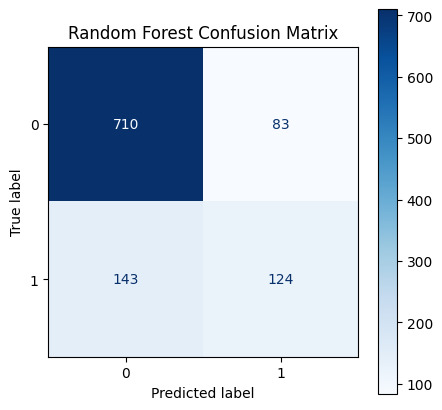

0.7867924528301887


In [65]:
#Random Forest Classifier
rf_model= RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

print(accuracy_score(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       793
           1       0.66      0.54      0.59       267

    accuracy                           0.81      1060
   macro avg       0.76      0.72      0.74      1060
weighted avg       0.81      0.81      0.81      1060



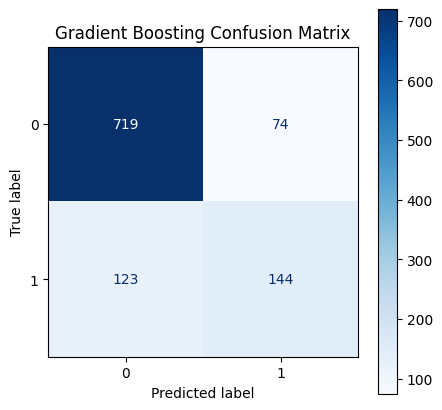

0.8141509433962264


In [66]:
# Gradient Boosting Classifier
gb_model=GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train,y_train)

y_pred_gb=gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(gb_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

print(accuracy_score(y_test, y_pred_gb))


*Logistic Regression	80.2%
Random Forest	78.7%
Gradient Boosting	81.4%*


*Gradient boosting Classifier achieves the highest Accuracy (81.4%), Precision (66%), and F1-Score (0.59) while matching the highest Recall (54%)*

**Hyperparameter Tuning**

In [69]:
gb_model.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [78]:
param_grid_expanded = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

In [81]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid = param_grid_expanded,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
grid_search.best_params_



Fitting 5 folds for each of 162 candidates, totalling 810 fits


{'learning_rate': 0.05,
 'max_depth': 4,
 'min_samples_split': 10,
 'n_estimators': 100,
 'subsample': 1.0}

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       793
           1       0.65      0.53      0.59       267

    accuracy                           0.81      1060
   macro avg       0.75      0.72      0.73      1060
weighted avg       0.80      0.81      0.80      1060



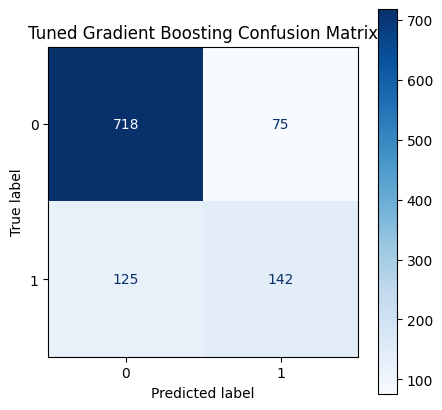

Tuned Model Accuracy: 0.8113


In [82]:
best_gb_model = grid_search.best_estimator_

y_pred_tuned = best_gb_model.predict(X_test)

print(cr(y_test, y_pred_tuned))

fig, ax = plt.subplots(figsize=(5, 5))
cm.from_estimator(best_gb_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Tuned Gradient Boosting Confusion Matrix")
plt.show()

print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

**predicting on test data**

In [98]:
data1=pd.read_csv("/content/Testing_data.csv")

In [99]:
data1['Churn'] = data1['Churn'].map({'Yes': 1, 'No': 0})
data1['TotalCharges'] = pd.to_numeric(data1['TotalCharges'], errors='coerce')

data1=data1.dropna(subset=['gender','OnlineSecurity'])

data1['MonthlyCharges']=data1['MonthlyCharges'].fillna(data1['MonthlyCharges'].median())
data1['TotalCharges']=data1['TotalCharges'].fillna(data1['TotalCharges'].median())

data1=data1.drop(columns=['customerID','PhoneService','TotalCharges'])

#Label Encoding
label=LabelEncoder()
data1['gender']=label.fit_transform(data1['gender'])
data1['Partner']=label.fit_transform(data1['Partner'])
data1['Dependents']=label.fit_transform(data1['Dependents'])
data1['PaperlessBilling']=label.fit_transform(data1['PaperlessBilling'])

#one hot encoding
categorical_cols = data1.select_dtypes(include=['object']).columns
data1 = pd.get_dummies(data1, columns=categorical_cols, drop_first=True,dtype=int)

data1['Lifetime_value_Proxy'] = data1['tenure'] * data1['MonthlyCharges']

if 'Contract_One year' in data1.columns:
    data1['Tenure_x_OneYearContract'] = data1['tenure'] * data1['Contract_One year']
if 'Contract_Two year' in data1.columns:
    data1['Tenure_x_TwoYearContract'] = data1['tenure'] * data1['Contract_Two year']

In [104]:

X_test_final = data1.drop(columns=['Churn'])
y_test_final = data1['Churn']

num_cols = ['tenure', 'MonthlyCharges', 'Lifetime_value_Proxy']
if 'Tenure_x_OneYearContract' in X_train.columns:
    num_cols.extend(['Tenure_x_OneYearContract', 'Tenure_x_TwoYearContract'])

X_test_final = X_test_final.reindex(columns=X_train.columns, fill_value=0)

X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

--- Final Test Set Evaluation (Tuned Gradient Boosting) ---
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1044
           1       0.27      0.31      0.29       365

    accuracy                           0.61      1409
   macro avg       0.51      0.51      0.51      1409
weighted avg       0.62      0.61      0.62      1409



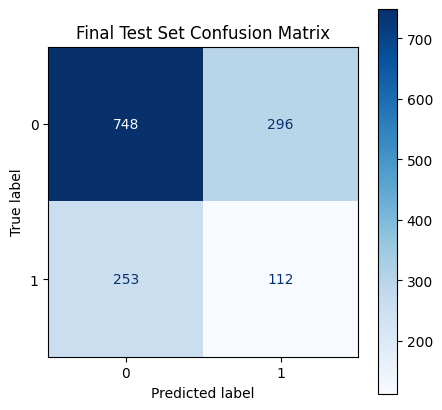

Final Test Accuracy: 0.6104


In [105]:
y_pred_final = best_gb_model.predict(X_test_final)

print("--- Final Test Set Evaluation (Tuned Gradient Boosting) ---")
print(cr(y_test_final, y_pred_final))

fig, ax = plt.subplots(figsize=(5, 5))
cm.from_predictions(y_test_final, y_pred_final, cmap='Blues', ax=ax)
plt.title("Final Test Set Confusion Matrix")
plt.show()

print(f"Final Test Accuracy: {accuracy_score(y_test_final, y_pred_final):.4f}")

In this supervised learning case study, a customer churn prediction pipeline was built by preprocessing a Telco dataset, handling missing values, encoding categorical variables, and engineering key interaction features such as a lifetime value proxy. After evaluating multiple algorithms, the **Gradient Boosting Classifier** outperformed Logistic Regression and Random Forest with a baseline validation accuracy of **81.4%**. This model was optimized using `GridSearchCV` to find the best hyperparameters (`learning_rate: 0.05`, `max_depth: 4`, `n_estimators: 100`), maintaining a strong validation accuracy of **81.1%**. However, when evaluated on the completely unseen final test dataset (`Testing_data.csv`), the model's accuracy dropped to **61.04%** (correctly predicting 748 non-churners and 112 churners), indicating a potential distribution shift between the training and test sets or a minor pipeline mismatch during feature scaling.